Here we will aim to implement the [[9,1,3]] Shor code incluing enoding, measureing stabilizers with an ancilla, decoding and comparing logical error rates to unencoded qubits

So our first goal is the encoding of a logical 1-qubit state spanned by the following staes,
|0L> = (000 + 111/sqrt2), |1L> = (000 - 111/sqrt2) 

In [92]:
# Qiskit imports
from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister,
)
from qiskit_ibm_runtime.circuit import MidCircuitMeasure

import numpy as np 
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [ ]:
qreg_data = QuantumRegister(9)
qreg_measure = QuantumRegister(4)
creg_data = ClassicalRegister(3, name="data")
creg_syndrome = ClassicalRegister(2, name="syndrome")
state_data = qreg_data[0]
ancillas_data = qreg_data[1:]

def build_qc():
    return QuantumCircuit(qreg_data, qreg_measure, creg_data, creg_syndrome)

def three_qubitencoding(circuit: QuantumCircuit):

    circuit.barrier(state_data, label="initialising state")
    circuit.cx(state_data, qreg_data[3])
    circuit.cx(state_data, qreg_data[6])

    circuit.h(qreg_data[0])
    circuit.h(qreg_data[3])
    circuit.h(qreg_data[6])
    
    circuit.barrier(qreg_data, label="Encoding initial state")
    return circuit



In [94]:
def nine_qubitencoding(circuit: QuantumCircuit):

    circuit.cx(qreg_data[0], qreg_data[1])
    circuit.cx(qreg_data[0], qreg_data[2])
    circuit.cx(qreg_data[3], qreg_data[4])
    circuit.cx(qreg_data[3], qreg_data[5])
    circuit.cx(qreg_data[6], qreg_data[7])
    circuit.cx(qreg_data[6], qreg_data[8])

    

    circuit.barrier(qreg_data, qreg_measure, label="Encoding to 9 qubit states")
    return circuit



To mention a bit about how we can solve bit flip errors with Shor's code. we first notice that in each of the 3 blocks that we have, we instill a 3 bit repetition code, which protects against bit flip errors, so by performing syndrome measurements and X error corrections descibed previously to each blokc we can dectect and correc up to one bit flip error per block 

Now about the phase flip errors, the outer qubits are what is able to dectect these errors, and the inner qubits can make it a slight bit more confusing. If a Z error were to occur on one of the inner qubits, we can have a relation with a CNOT gate and a Z gate, that allows us to see that it is equivalent to a Z error on the outer qubits.(i.e equvialent Z error prior to encoding)

Do a suggestion to dectecting and correcting these qubits is to DECODE the inner code, leaving us with the 3 qubits used for the outerencoding. We then check these outer qubits for Z errors, before REencoding bringing us back to the 9qubit encoding. 
Now we can do it exactly that way, which we would require 16 CNOT gates, but with Some CNOT relations we can bring it down to 12CNOTS,

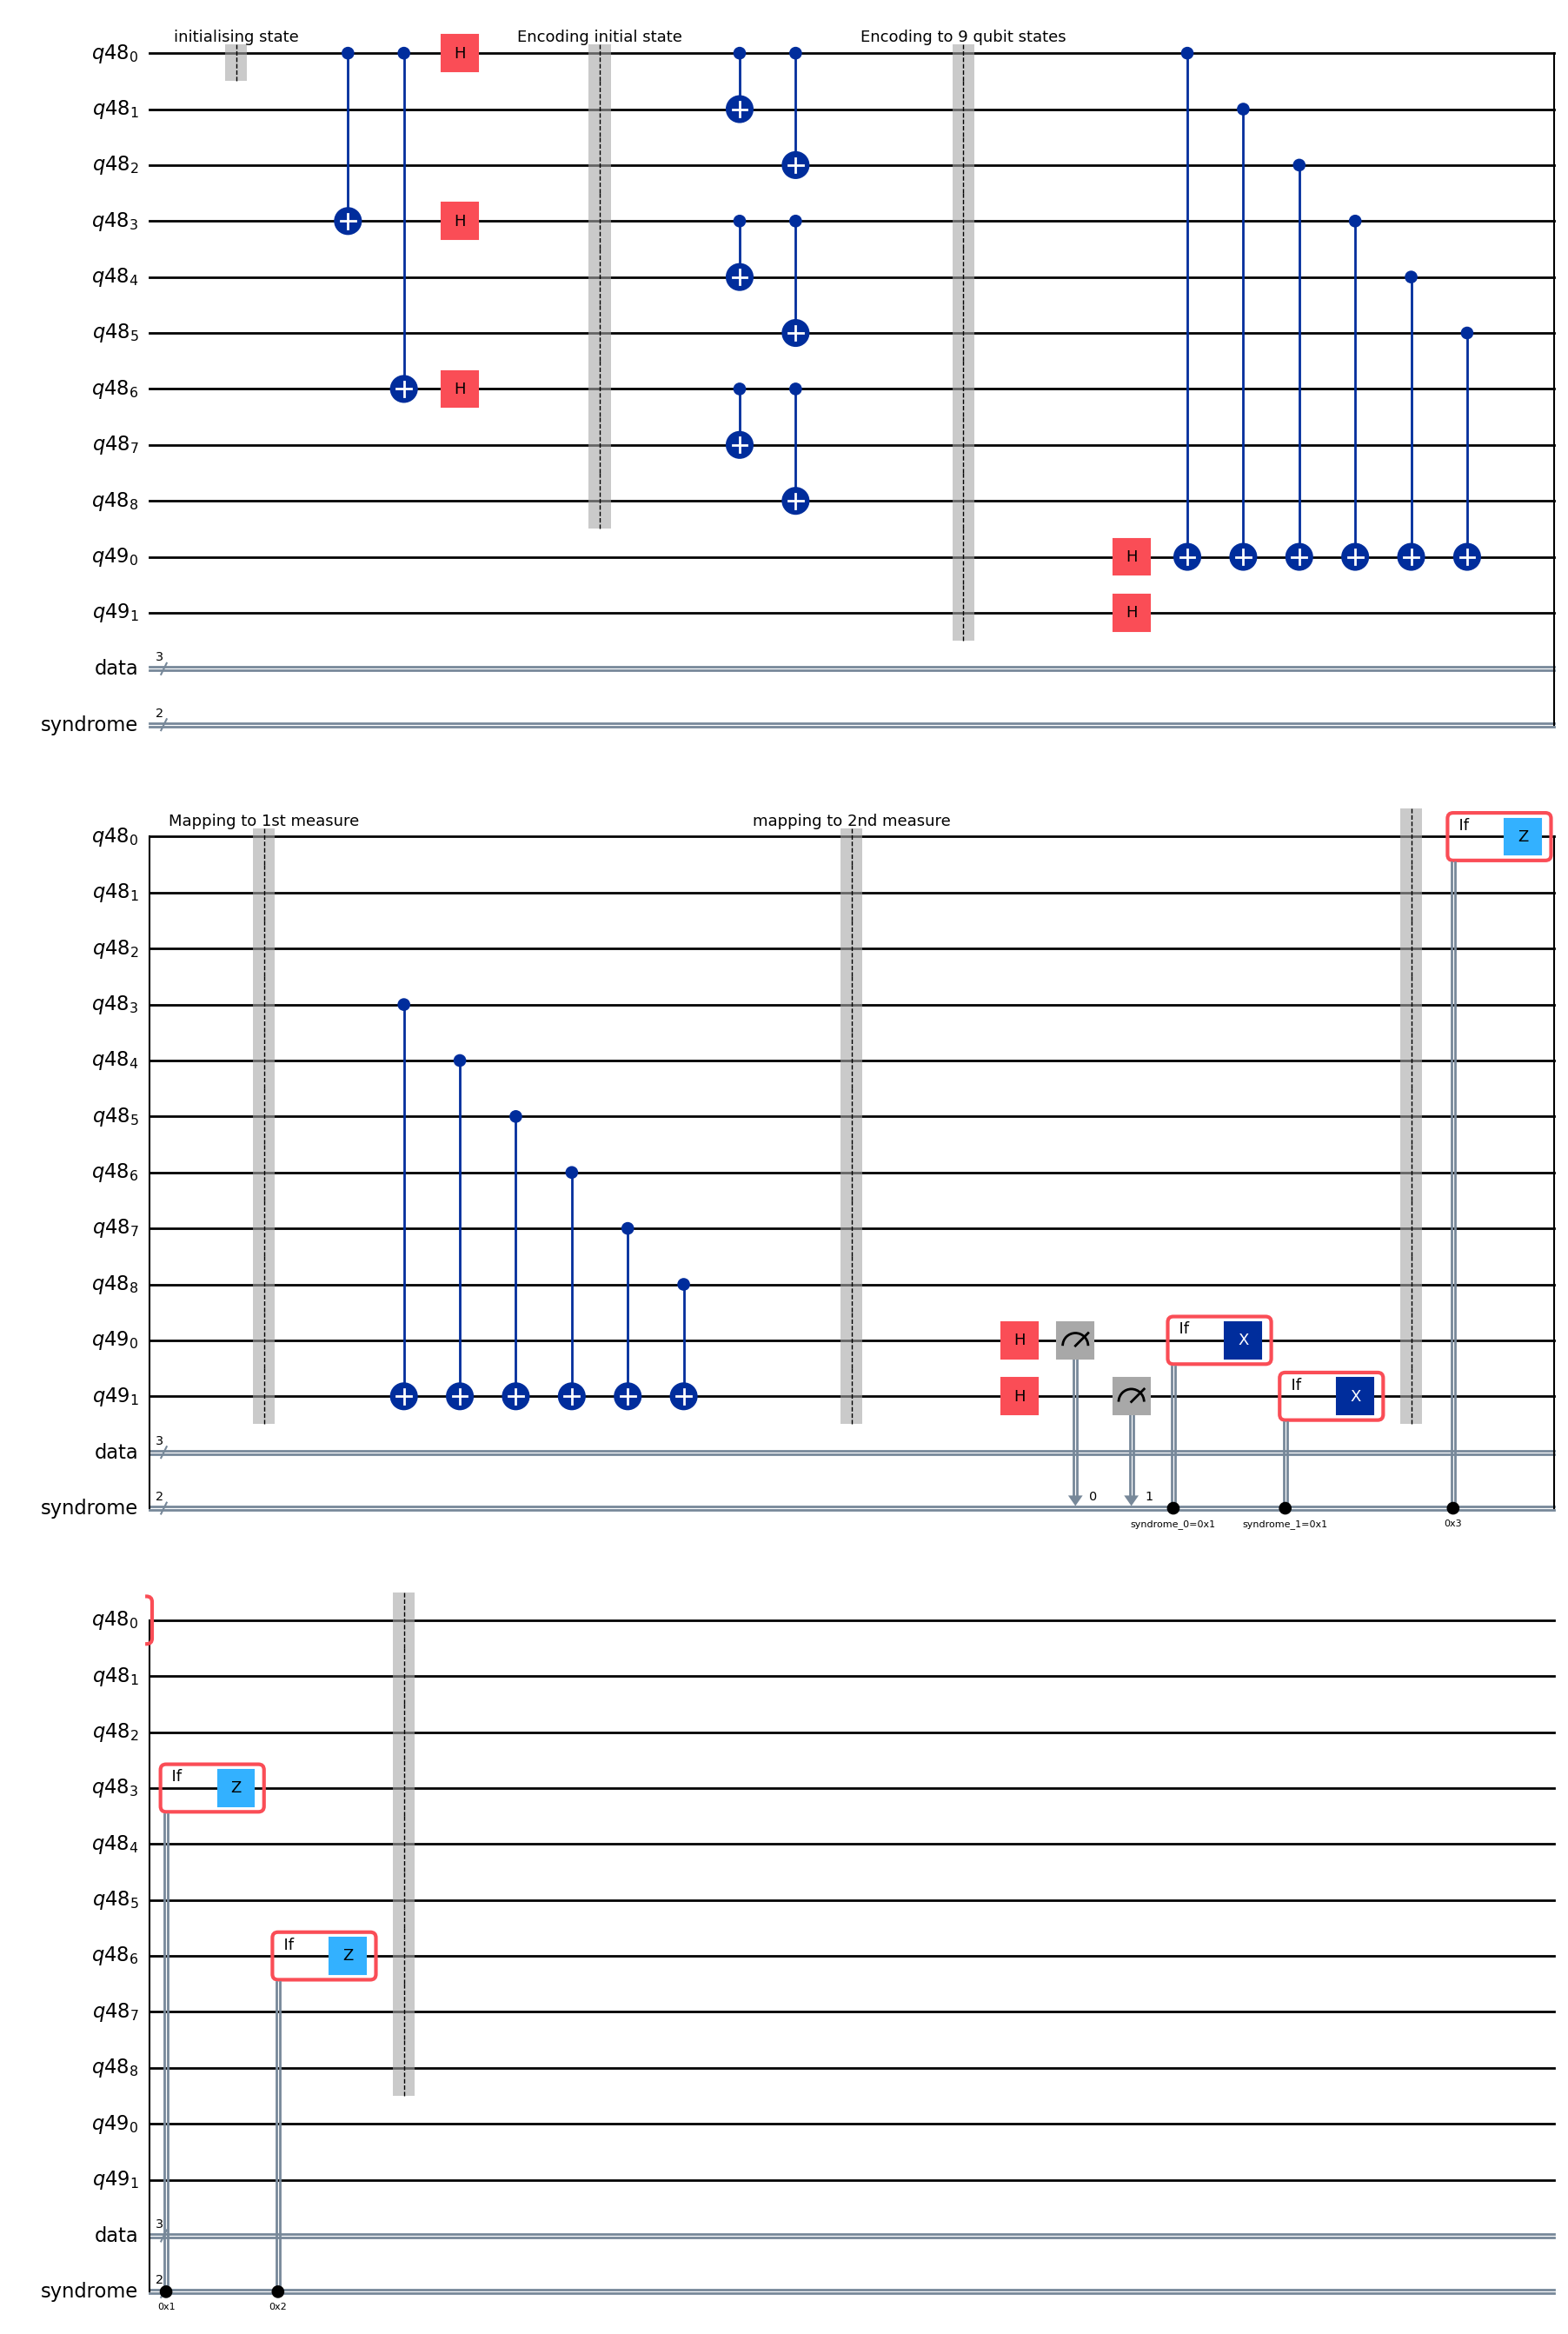

In [ ]:
def Bitflip_error_dectection(circuit:QuantumCircuit):
    circuit.cx(qreg_data[0], qreg_measure[2])
    circuit.cx(qreg_data[3], qreg_measure[2])
    circuit.cx(qreg_data[3], qreg_measure[3])
    circuit.cx(qreg_data[4], qreg_measure[3])

    return circuit

def Measurements(circuit: QuantumCircuit):

    circuit.measure(qreg_measure[2], creg_syndrome)
    circuit.measure(qreg_measure[3], creg_syndrome)

    with circuit.if_test((creg_syndrome[0], 1)):
        circuit.x(qreg_measure[0])
    with circuit.if_test((creg_syndrome[1], 1)):
        circuit.x(qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)
    
    return circuit

def bitflip_Correction_protocol(circuit: QuantumCircuit):
    with circuit.if_test((creg_syndrome, 3)):
        circuit.z(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.z(qreg_data[3])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.z(qreg_data[6])
    circuit.barrier(qreg_data)
    return circuit
    

def Phase_error_dectection(circuit: QuantumCircuit):
    circuit.h(qreg_measure)

    for i in qreg_data[0:6]:
        circuit.cx(i, qreg_measure[0])
    circuit.barrier(qreg_data, qreg_measure, label= "Mapping to 1st measure")
    for i in qreg_data[3:9]:
        circuit.cx(i, qreg_measure[1])
    circuit.barrier(qreg_data, qreg_measure, label= "mapping to 2nd measure")


    circuit.h(qreg_measure)
    return circuit

def Measurements(circuit: QuantumCircuit):

    circuit.measure(qreg_measure, creg_syndrome)

    with circuit.if_test((creg_syndrome[0], 1)):
        circuit.x(qreg_measure[0])
    with circuit.if_test((creg_syndrome[1], 1)):
        circuit.x(qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)
    
    return circuit

def Correction_protocol(circuit: QuantumCircuit):
    with circuit.if_test((creg_syndrome, 3)):
        circuit.z(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.z(qreg_data[3])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.z(qreg_data[6])
    circuit.barrier(qreg_data)
    return circuit
    


def build_circuit():
    circuit= build_qc()
    circuit= three_qubitencoding(circuit)
    circuit= nine_qubitencoding(circuit)
    circuit= Phase_error_dectection(circuit)
    circuit= Measurements(circuit)
    circuit= Correction_protocol(circuit)
    return circuit

tester= build_circuit()
tester.draw("mpl")